# Monte Carlo
In this notebook, we shall explore the Monte-Carlo approach.

In [25]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np

# Load data  
log_returns = pd.read_csv('../data/log_returns.csv', index_col=0, parse_dates=True)
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

portfolio_returns = log_returns.dot(weights)

In [26]:
import numpy as np
import matplotlib.pyplot as plt


def monte_carlo_var(log_returns, weights, portfolio_value=1_000_000, simulations=10_000, horizon=1, confidence_level=0.99):
    weights = np.array(weights)
    mean_returns = log_returns.mean().values
    cov_matrix = log_returns.cov().values

    # Cholesky decomposition for generating correlated random returns
    L = np.linalg.cholesky(cov_matrix)

    simulated_portfolio_returns = []

    for _ in range(simulations):
        # Generate correlated random shocks
        z = np.random.standard_normal(len(weights))
        correlated_shocks = L @ z # @ is the matrix multiplication operator in Python 3.5+

        # Simulate returns for each asset
        simulated_returns = mean_returns + correlated_shocks

        # Portfolio return
        portfolio_return = np.dot(weights, simulated_returns)
        simulated_portfolio_returns.append(portfolio_return)

    simulated_portfolio_returns = np.array(simulated_portfolio_returns)

    mc_var = -np.percentile(simulated_portfolio_returns, (1 - confidence_level) * 100)
    mc_cvar = -simulated_portfolio_returns[simulated_portfolio_returns < -mc_var].mean()

    return {'simulated_returns': simulated_portfolio_returns, 'VaR': mc_var * portfolio_value, 'CVaR': mc_cvar * portfolio_value}




Next, we extend this to multi-day horizons using Geometric Brownian Motion (GBM) paths.

In [27]:
def monte_carlo_paths(log_returns, weights, portfolio_value=1_000_000, simulations=1000, horizon=252):
    weights = np.array(weights)
    mean_returns = log_returns.mean().values
    cov_matrix = log_returns.cov().values

    # Cholesky decomposition for generating correlated random returns
    L = np.linalg.cholesky(cov_matrix)

    all_paths = []

    for _ in range(simulations):
        path = [portfolio_value]
        for t in range(horizon):
            z = np.random.standard_normal(len(weights))
            correlated_shocks = L @ z # @ is the matrix multiplication operator in Python 3.5+
            daily_returns = mean_returns + correlated_shocks
            portfolio_daily_return = np.dot(weights, daily_returns)
            path.append(path[-1] * (1 + portfolio_daily_return))

        all_paths.append(path)

    return np.arrayall_paths

The next code, is to clear the cache memory

In [28]:
import importlib
import src.monte_carlo as mc_module
importlib.reload(mc_module)
from src.monte_carlo import monte_carlo_var, monte_carlo_paths

Next, we make the visualization of the Monte-Carlo paths.

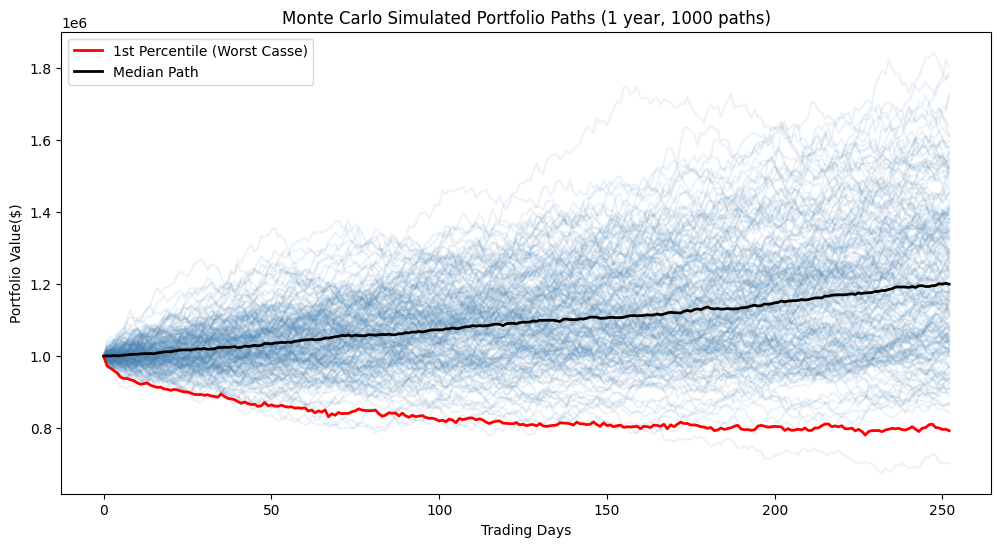

In [29]:
paths = monte_carlo_paths(log_returns, weights)

plt.figure(figsize=(12, 6))
plt.plot(paths[:200].T, alpha=0.1, color='steelblue')  # Plot the first 200 paths for clarity
plt.plot(np.percentile(paths, 1, axis=0), color='red', linewidth=2, label='1st Percentile (Worst Casse)')
plt.plot(np.percentile(paths, 50, axis=0), color='black', linewidth=2, label='Median Path')
plt.title('Monte Carlo Simulated Portfolio Paths (1 year, 1000 paths)')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value($)')
plt.legend()
plt.savefig('../outputs/monte_carlo_paths.png', dpi=150)  # Save the plot to a file.
plt.show()
